In [1]:
#IMPORT LIBRARIES

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier

from xgboost import XGBClassifier

In [3]:
#LOAD DATASET

In [4]:
X_train = pd.read_csv('train/X_train.txt', sep='\s+', header=None)
y_train = pd.read_csv('train/y_train.txt', header=None)

X_test = pd.read_csv('test/X_test.txt', sep='\s+', header=None)
y_test = pd.read_csv('test/y_test.txt', header=None)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (7352, 561)
Testing Data Shape: (2947, 561)


In [5]:
#ADD FEATURE NAMES

In [6]:
features = pd.read_csv('features.txt', sep='\s+', header=None)

feature_names = features[1].values

X_train.columns = feature_names
X_test.columns = feature_names

print(X_train.head())

   tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  \
0           0.288585          -0.020294          -0.132905         -0.995279   
1           0.278419          -0.016411          -0.123520         -0.998245   
2           0.279653          -0.019467          -0.113462         -0.995380   
3           0.279174          -0.026201          -0.123283         -0.996091   
4           0.276629          -0.016570          -0.115362         -0.998139   

   tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  tBodyAcc-mad()-Y  \
0         -0.983111         -0.913526         -0.995112         -0.983185   
1         -0.975300         -0.960322         -0.998807         -0.974914   
2         -0.967187         -0.978944         -0.996520         -0.963668   
3         -0.983403         -0.990675         -0.997099         -0.982750   
4         -0.980817         -0.990482         -0.998321         -0.979672   

   tBodyAcc-mad()-Z  tBodyAcc-max()-X  ...  fBodyBodyGyr

In [7]:
#MAP ACTIVITY LABELS

In [8]:
activity_labels = {
1: "Walking",
2: "Walking Upstairs",
3: "Walking Downstairs",
4: "Sitting",
5: "Standing",
6: "Laying"
}

y_train = y_train[0].map(activity_labels)
y_test = y_test[0].map(activity_labels)

print(y_train.head())

0    Standing
1    Standing
2    Standing
3    Standing
4    Standing
Name: 0, dtype: object


In [9]:
#VISUALIZATION

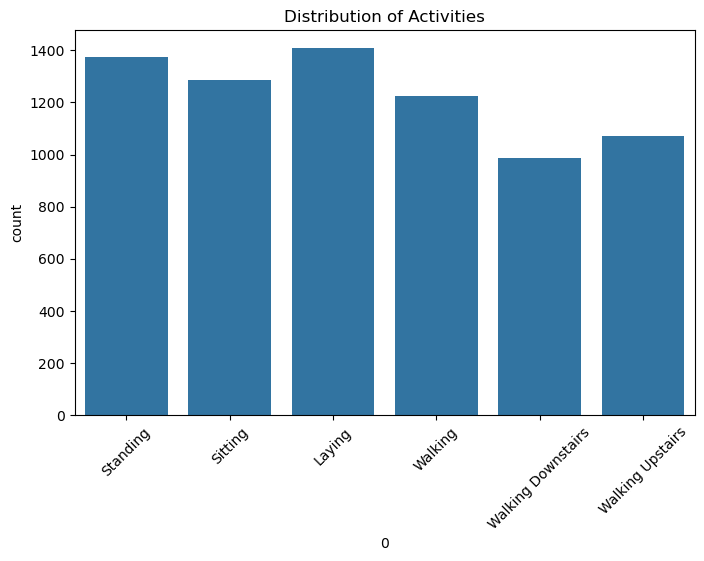

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(x=y_train)

plt.title("Distribution of Activities")
plt.xticks(rotation=45)

plt.show()

In [11]:
#DECISION TREE

In [12]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8605361384458772


In [13]:
#RANDOM FOREST

In [14]:
rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9300984051577876


In [15]:
#KNN

In [16]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9002375296912114


In [17]:
#ADABOOST

In [18]:
adb_model = AdaBoostClassifier(n_estimators=50)

adb_model.fit(X_train, y_train)

adb_pred = adb_model.predict(X_test)

adb_accuracy = accuracy_score(y_test, adb_pred)

print("AdaBoost Accuracy:", adb_accuracy)

AdaBoost Accuracy: 0.3491686460807601


In [19]:
#LABEL ENCODING

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [21]:
#CONVERT DATASET FOR XGBOOST

In [22]:
X_train_xgb = X_train.values
X_test_xgb = X_test.values

In [23]:
#XGBOOST

In [24]:
xgb = XGBClassifier(eval_metric='mlogloss')

xgb.fit(X_train_xgb, y_train_encoded)

xgb_pred = xgb.predict(X_test_xgb)

xgb_accuracy = accuracy_score(y_test_encoded, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.9379029521547336


In [25]:
#ACCURACY COMPARISON

In [26]:
results = {
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy,
    "KNN": knn_accuracy,
    "AdaBoost": adb_accuracy,
    "XGBoost": xgb_accuracy
}

for model, acc in results.items():
    print(model, ":", acc)

Decision Tree : 0.8605361384458772
Random Forest : 0.9300984051577876
KNN : 0.9002375296912114
AdaBoost : 0.3491686460807601
XGBoost : 0.9379029521547336


In [27]:
#GRAPH COMPARISON

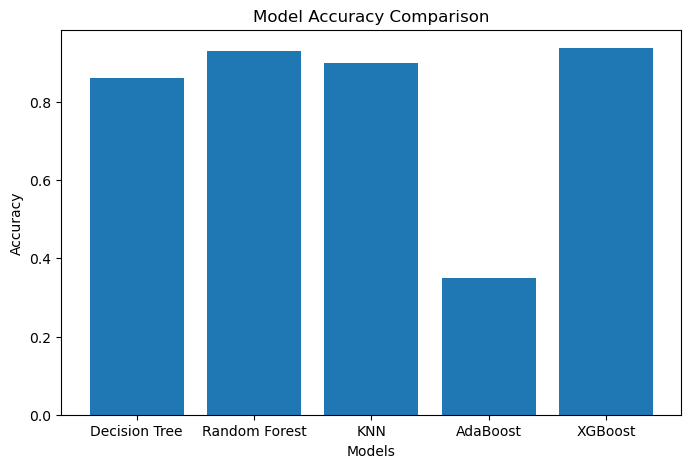

In [28]:
models = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [29]:
#CONFUSION MATRIX

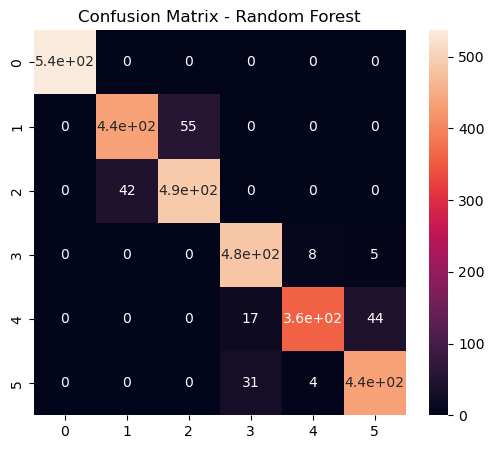

In [30]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True)

plt.title("Confusion Matrix - Random Forest")

plt.show()

In [31]:
print(classification_report(y_test, rf_pred))

                    precision    recall  f1-score   support

            Laying       1.00      1.00      1.00       537
           Sitting       0.91      0.89      0.90       491
          Standing       0.90      0.92      0.91       532
           Walking       0.91      0.97      0.94       496
Walking Downstairs       0.97      0.85      0.91       420
  Walking Upstairs       0.90      0.93      0.91       471

          accuracy                           0.93      2947
         macro avg       0.93      0.93      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



In [32]:
#FEATURE IMPORTANCE

In [33]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9324737020699015


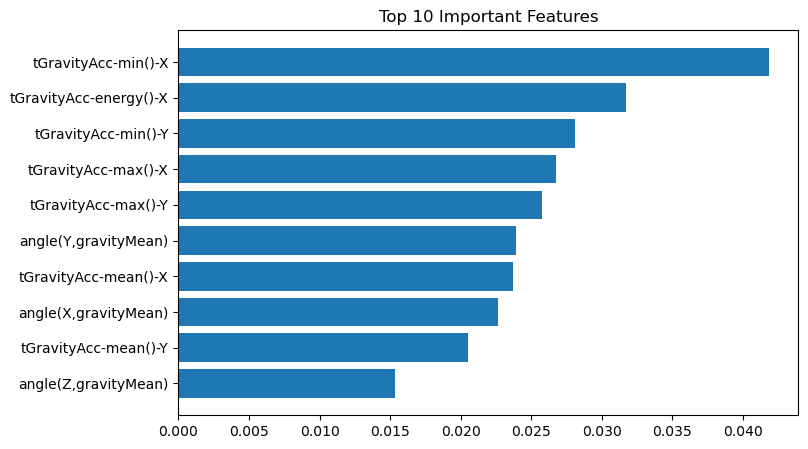

In [34]:
importances = rf.feature_importances_

indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,5))

plt.barh(range(len(indices)), importances[indices])

plt.yticks(range(len(indices)), X_train.columns[indices])

plt.title("Top 10 Important Features")

plt.show()